# 背景
## 项目简介

本教材旨在使用可运行的代码实例穿插文本讲解，详细介绍一台赛车从指标体系构建到生成整套悬架硬点、弹簧阻尼搭配设计的流程。本文将介绍赛车驾驶及整车动力学基础。

## FSAE的本质

首先我们应当认识到，在大学生方程式赛事高研发自由度的特性下，一定存在某一辆赛车，是在综合考虑了车队人力资源、车手驾驶偏好与赛道赛事特性之后的理论最快车；且这种最优解对每一个车队来说都是独特的。由于答辩等静态项目在理想情况下考察的是参赛队员寻找这个最优解的过程的严谨性和合理性，我们可以提出：大学生方程式赛车设计的最终目的有且仅有寻求这个综合考虑下的最优解。

综合考虑人力资源、驾驶偏好、和赛道特性听起来貌似是个需要职业赛车队使用昂贵的专业软件进行大量的虚拟原型开发才能做到的事情，但是只要我们不断地通过定性分析提取事物的本质并进行化简，那么其实就可以把“什么是最好的赛车”这个泛而空洞的话题转化为简单明了的数字指标。接下来我们将把这个抽象的概念一步步落实。

## V型工作流

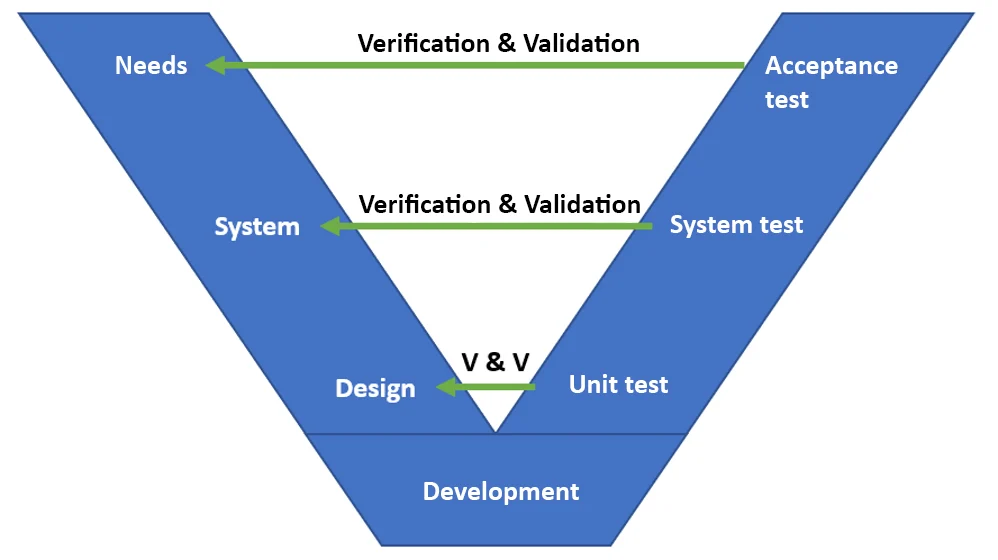

合理的工程项目应该遵循如上的V型工作流程，设计阶段将宽泛的需求逐步细化到每个零件，然后再在加工阶段逐步验证通过为整车。

下面我们用一个简单的摆臂吊耳设计来介绍这个流程：

```mermaid
flowchart TD
    A[整车指标：做出最快的赛车] --> B
    B[吊耳如何影响整车性能？] --> C[重量]
    B -->|轮胎接地角过大/过小会让车变慢| D[刚度]
    C -->|轻车比重车快| E[越轻越好（优化指标）]
    D --> F[刚度足够接地角与主销定位不产生显著变化（限制指标）]
```
大多数读者可能对到此的内容都比较熟悉，但是如果仅仅做了这些之后就满心欢喜的拿着这些指标跑拓扑优化或是有限元+手动优化，然后做出零件直接装车，那V型工作流应该叫做"1"型工作流。这样的开发并不能保证零件对指标的达成率，也就不能被称之为严谨。若要达成V的另一边，则需要从具体的零部件指标开始向上回归到整车指标的验证：


```mermaid
flowchart TD
    A[材料（7075 T6铝合金）] -->|测试材料性质，输入仿真| B[零件（摆臂吊耳）]
    B -->|单独测试确认制成零件的刚度| C[组件（上摆臂组件）]
    C -->|确认摆臂外球头总形变符合要求| D[总成]
    D -->|确认接地角变化符合要求| E[整车]
```

## 概念设计

在了解了V型工作流之后，回归FSAE赛车的问题上，不难抛出一个问题：“我们如何知道赛车快不快呢？”
虽然这个问题可以通过诸如多体动力学（MBD）仿真或实车驾驶的方式解决，但是前文中提到，整车模型是一定需要经过验证的。但即使是随便挥挥手就有几百万测试预算的OEM也不一定有完美验证MBD模型的实力，FSAE就更不用提了。况且，在至多两个月的概念设计期内，很难对每一种概念都进行精细建模并进行拟合。综上，我们需要的是对赛车这个复杂的系统进行大幅度化简与拆分，再使用方便拟合的拆分模型进行定量分析。

什么是代表一台赛车最简单的方式呢？赛车是一个使用最短时间经过某一条路径的物体。进一步说，在FSAE这样场地较为平整、近似为二位平面的场地上，一台赛车整体性的运动轨迹其实可以被两个维度描述。我们只要知道了这个物体实时的速度向量和位置向量，就知道了这个物体状态的一切。

此时，赛车的运动状态被简化为了一个质点，而赛车的性能此时又应该如何建模呢？显然，我们评价一台赛车所有客观性能的一切话语——动力、过弯、刹车等——都与且仅与加速度有关。由此可得，赛车的性能由其加速度描述。
